Imports

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

Import Data and Fill NaN Values

In [ ]:
DATA_GLOB = "data/PWC/*.csv"

exclude_files = ["hourly_Temp_data", "house_matthijs_solar_offset", "house_marios", "house_michelle", "house_robert", "house_levi", "house_slicherstraat46", "house_geert", "house_thomas", "house_frans"]
csv_files = [f for f in glob.glob(DATA_GLOB) if not any(excl in f for excl in exclude_files)]

print("Found files:", csv_files)

mapping = {
    "travis": 0,
    "kevin": 1,
    "matthijs": 2,
    "riaan": 3,
    "catharinaland50": 4,
    "neea": 5,
    "manolis": 6,
    "rick": 7,
    "jet": 8,
    "robin": 9
}

# This function loads the hourly energy consumption data from a CSV file, processes it to ensure it has a DateTime index, and resamples it to ensure it has hourly frequency.
# The function's parameter is :
# - path: The path to the CSV file containing the hourly energy consumption data.
def load_household_hourly(path):
    df = pd.read_csv(path)
    df.rename(columns={'time': 'Date', 'main': 'Volume'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.set_index('Date')

    df = df.resample('1h').mean()
    df = df.reset_index()    
    
    return df

# This function takes the hourly data and creates a daily matrix where each row corresponds to a day and each column corresponds to an hour of the day.
# This function's parameter is :
# - df_hourly: A DataFrame containing hourly energy consumption data with a 'Date' column and a 'Volume' column.
def make_daily_matrix(df_hourly):
    df = df_hourly.copy()
    df['Day'] = df['Date'].dt.date
    df['Hour'] = df['Date'].dt.hour
    df['Weekday'] = df['Date'].dt.weekday
    df['Month'] = df['Date'].dt.month

    group_median = (
        df
        .groupby(['Month', 'Weekday', 'Hour'])['Volume']
        .median()
        )
    def fill_with_group_median(row):
        if pd.isna(row['Volume']):
            return group_median.loc[(row['Month'], row['Weekday'], row['Hour'])]
        else:
            return row['Volume']
    
    # Number of missing values in Volume before filling with group median
    missing_count = df['Volume'].isna().sum()
    print(f"Missing values before filling: {missing_count} out of {len(df)} ({missing_count/len(df)*100:.2f}%)")
    missing_groups = (df['Volume'].isna() != df['Volume'].isna().shift()).cumsum()
    longest_gap = df[df['Volume'].isna()].groupby(missing_groups).size().max()
    print(f"Longest gap of missing values : {longest_gap} entries, which is {longest_gap / len(df) * 100:.2f}% of total entries.")
    
    df['Volume'] = df.apply(fill_with_group_median, axis=1)


    daily_matrix = df.pivot_table(index='Day',
                                  columns='Hour',
                                  values='Volume')
    daily_matrix = daily_matrix.dropna()
    daily_matrix = daily_matrix.reindex(columns=range(24))
    return daily_matrix


Found files: ['data/PWC/house_travis.csv', 'data/PWC/house_kevin.csv', 'data/PWC/house_matthijs.csv', 'data/PWC/house_riaan.csv', 'data/PWC/house_catharinaland50.csv', 'data/PWC/house_robin.csv', 'data/PWC/house_neea.csv', 'data/PWC/house_manolis.csv', 'data/PWC/house_rick.csv', 'data/PWC/house_jet.csv']


DBSCAN Clustering Function

In [3]:
# This function applies DBSCAN to the daily profiles and computes metrics about the clustering results.
# This Function's parameters are :
# - daily_matrix: A DataFrame where each row corresponds to a day and each column corresponds to an hour of the day, containing the energy consumption values.
def dbscan_daily_profiles(daily_matrix):
    X = daily_matrix.values

    daily_energy = X.sum(axis=1)
    avg_daily_energy = daily_energy.mean()

    eps = 0.10 * avg_daily_energy   
    min_samples = 2

    db = DBSCAN(eps=eps,
                min_samples=min_samples,
                metric='euclidean')
    labels = db.fit_predict(X)

    n_days = len(labels)
    n_outliers = np.sum(labels == -1)
    frac_outliers = n_outliers / n_days

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    metrics = {
        "n_days": n_days,
        "n_clusters": n_clusters,
        "n_outliers": n_outliers,
        "frac_outliers": frac_outliers,
        "avg_daily_energy": avg_daily_energy,
        "eps_used": eps,
    }
    return labels, metrics


Main Loop to Process Each Household and Run DBSCAN

In [4]:
house_metrics = []

for path in csv_files:

    hid = os.path.splitext(os.path.basename(path))[0]
    hid = hid.split("_")[1] if "_" in hid else hid
    if hid in mapping:
        hid = mapping[hid]
    print("Processing", hid)

    df_hourly = load_household_hourly(path)
    daily_matrix = make_daily_matrix(df_hourly)

    if len(daily_matrix) < 5:
        print(f"  Not enough full days for {hid}, skipping.")
        print("  daily_matrix length:", len(daily_matrix))
        continue

    labels, metrics = dbscan_daily_profiles(daily_matrix)
    metrics["HouseholdID"] = hid
    print(f"  Found {metrics['n_clusters']} clusters, "
          f"{metrics['n_outliers']} outliers "
          f"out of {metrics['n_days']} days.")
    house_metrics.append(metrics)

house_features = pd.DataFrame(house_metrics).set_index("HouseholdID")
print(house_features)


Processing 0
Missing values before filling: 0 out of 1521 (0.00%)
Longest gap of missing values : nan entries, which is nan% of total entries.
  Found 5 clusters, 22 outliers out of 63 days.
Processing 1
Missing values before filling: 18 out of 672 (2.68%)
Longest gap of missing values : 18 entries, which is 2.68% of total entries.
  Found 1 clusters, 17 outliers out of 28 days.
Processing 2
Missing values before filling: 18 out of 744 (2.42%)
Longest gap of missing values : 10 entries, which is 1.34% of total entries.
  Found 3 clusters, 24 outliers out of 31 days.
Processing 3
Missing values before filling: 0 out of 744 (0.00%)
Longest gap of missing values : nan entries, which is nan% of total entries.
  Found 1 clusters, 25 outliers out of 30 days.
Processing 4
Missing values before filling: 0 out of 662 (0.00%)
Longest gap of missing values : nan entries, which is nan% of total entries.
  Found 1 clusters, 13 outliers out of 27 days.
Processing 9
Missing values before filling: 123

Prepare Data for second clustering run

In [ ]:
# Features to cluster on
feat_cols = ["frac_outliers", "n_clusters", "avg_daily_energy"]

X_house = house_features[feat_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_house)


Using the Elbow Method to Determine Optimal Epsilon for DBSCAN

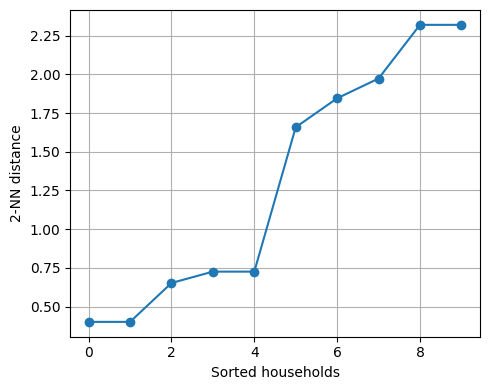

In [ ]:
k = 2
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

k_dist = np.sort(distances[:, k-1])

plt.figure(figsize=(5,4))
plt.plot(k_dist, marker='o')
plt.ylabel(f"{k}-NN distance")
plt.xlabel("Sorted households")
plt.grid(True)
plt.tight_layout()
plt.show()


DBSCAN Clustering second run

In [7]:
eps_users = 0.75

db_users = DBSCAN(eps=eps_users, min_samples=2)
user_labels = db_users.fit_predict(X_scaled)

house_features["cluster"] = user_labels
print(house_features)


             n_days  n_clusters  n_outliers  frac_outliers  avg_daily_energy  \
HouseholdID                                                                    
0                63           5          22       0.349206      11103.570263   
1                28           1          17       0.607143       3648.582934   
2                31           3          24       0.774194       7489.114048   
3                30           1          25       0.833333      15326.377330   
4                27           1          13       0.481481      12207.970112   
9                37           1           8       0.216216       7380.232810   
5                58           2          49       0.844828       6514.828985   
6                28           1          15       0.535714       4286.173678   
7                80           6          39       0.487500       2870.127307   
8                24           2          12       0.500000       5230.589378   

                eps_used  cluster  
Hou

Final metrics and visualization

         frac_outliers  n_clusters  avg_daily_energy
cluster                                             
-1            0.473547    2.800000       9777.655565
 0            0.547619    1.333333       4388.448663
 1            0.809511    2.500000       7001.971516

Cluster -1:
[0, 3, 4, 9, 7]

Cluster 0:
[1, 6, 8]

Cluster 1:
[2, 5]


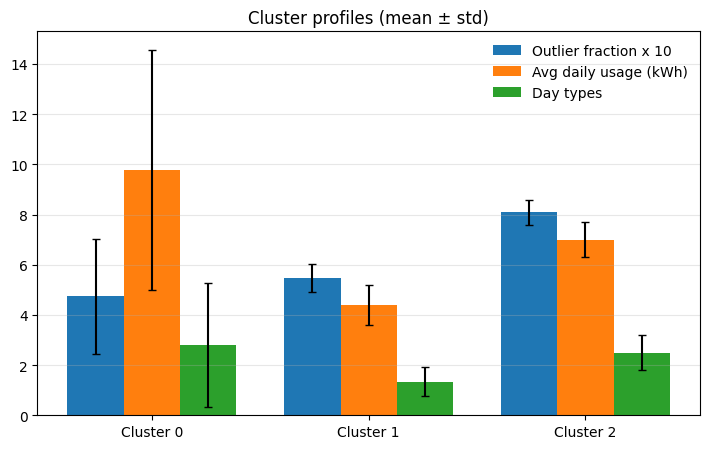

In [8]:
# basic summary
print(house_features.groupby("cluster")[feat_cols].mean())

# which households in each cluster
for c, sub in house_features.groupby("cluster"):
    print(f"\nCluster {c}:")
    print(sub.index.tolist())

plot_df = house_features.copy()
# Rename for readability in plots
plot_df = plot_df.rename(columns={
    "frac_outliers": "Outlier fraction",
    "n_clusters": "Day types",
    "avg_daily_energy": "Avg daily usage (Wh)"
})

if plot_df.empty:
    raise ValueError("plot_df is empty after filtering; check clustering labels / include_noise flag.")

clusters_sorted = sorted(plot_df["cluster"].unique())

features = ["Outlier fraction", "Avg daily usage (Wh)", "Day types"]

cluster_stats = (
    plot_df
    .groupby("cluster")[features]
    .agg(["mean", "std"])
)

# Reformat for plotting
means = cluster_stats.xs("mean", axis=1, level=1).loc[clusters_sorted]
stds  = cluster_stats.xs("std",  axis=1, level=1).loc[clusters_sorted].fillna(0.0)

means['Avg daily usage (Wh)'] = means['Avg daily usage (Wh)'] / 1000  # scale up for visibility
means.rename(columns={'Avg daily usage (Wh)': 'Avg daily usage (kWh)'}, inplace=True)
means['Outlier fraction'] = means['Outlier fraction'] * 10  # convert
means.rename(columns={'Outlier fraction': 'Outlier fraction x 10'}, inplace=True)
stds['Avg daily usage (Wh)'] = stds['Avg daily usage (Wh)'] / 1000  # scale up for visibility
stds.rename(columns={'Avg daily usage (Wh)': 'Avg daily usage (kWh)'}, inplace=True)
stds['Outlier fraction'] = stds['Outlier fraction'] * 10
stds.rename(columns={'Outlier fraction': 'Outlier fraction x 10'}, inplace=True)

# rename features for plotting
features = ["Outlier fraction x 10", "Avg daily usage (kWh)", "Day types"]
x = np.arange(len(clusters_sorted))
width = 0.26

plt.figure(figsize=(7.2, 4.6))
ax = plt.gca()

for i, feat in enumerate(features):
    ax.bar(
        x + (i - 1) * width,
        means[feat].values,
        width=width,
        yerr=stds[feat].values,
        capsize=3,
        label=feat
    )

ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {c + 1}" for c in clusters_sorted])
ax.set_title("Cluster profiles (mean ± std)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()